In [86]:
# Installs only if needed (run once)
pkgs <- c(
  "tidyverse","tm","SnowballC","caret","e1071","textclean","tidytext","wordcloud",
  "quanteda","klaR","pROC","slam","Matrix","stringi"
)
to_install <- pkgs[!pkgs %in% rownames(installed.packages())]
if (length(to_install)) install.packages(to_install)

# Load quietly to reduce console noise
suppressPackageStartupMessages({
  library(tidyverse)  # dplyr/stringr/readr/ggplot2, etc.
  library(tm)         # classic text mining (Corpus, DocumentTermMatrix)
  library(SnowballC)  # stemming
  library(caret)      # ML utilities (splits, metrics, training API)
  library(e1071)      # naiveBayes + SVM deps; confusionMatrix deps via caret
  library(textclean)  # optional text fixes (not heavy)
  library(tidytext)   # optional for future feature work
  library(wordcloud)  # optional visualization
  library(quanteda)   # loaded but not used heavily (kept to match Amber)
  library(klaR)       # Naive Bayes backend for caret (not used directly here)
  library(pROC)       # ROC/AUC
  library(slam)       # fast ops on 'tm' sparse matrices
  library(Matrix)     # general sparse matrix utilities
  library(stringi)    # fast word counts
})

# Reproducibility seed (used throughout)
set.seed(123)

In [87]:
# =========================
# CELL 2: LOAD & LABEL DATA
# -------------------------
# • Uses Kaggle "True.csv" and "Fake.csv".
# • Adds label factor: FAKE (positive class) vs REAL.
# • Chooses a text field robustly:
#     - Prefer full 'text', else 'title', else first column as fallback.
# =========================

# Colab-friendly: use /content if present, else current folder
data_dir <- if (dir.exists("/content")) "/content" else "."

# Read CSVs WITHOUT turning strings into factors (we'll control factors ourselves)
realNews <- read.csv(file.path(data_dir, "True.csv"), stringsAsFactors = FALSE)
fakeNews <- read.csv(file.path(data_dir, "Fake.csv"), stringsAsFactors = FALSE)

# Attach labels
realNews$label <- "REAL"
fakeNews$label <- "FAKE"

# Bind and set factor levels (FAKE = positive class for metrics)
allNews <- bind_rows(realNews, fakeNews) |>
  mutate(label = factor(label, levels = c("FAKE","REAL")))

# Choose which text to use: prefer article text; fallback to title; else first column
txt_col <- dplyr::case_when(
  "text"  %in% names(allNews) ~ "text",
  "title" %in% names(allNews) ~ "title",
  TRUE ~ names(allNews)[1]
)

# If both title and text exist, concatenate for richer signal; else just chosen column
allNews$text_full <- if (all(c("title","text") %in% names(allNews))) {
  paste(allNews$title, allNews$text)
} else {
  allNews[[txt_col]]
}

# Drop empty rows to avoid NA/zero-length issues downstream
allNews <- allNews |> filter(!is.na(text_full) & nzchar(text_full))

# Quick sanity check
summary(allNews$label)

head(realNews[, 1:5])
head(fakeNews[, 1:5])



FAKE  REAL 
23481 21417

title                                                                
1 As U.S. budget fight looms, Republicans flip their fiscal script     
2 U.S. military to accept transgender recruits on Monday: Pentagon     
3 Senior U.S. Republican senator: 'Let Mr. Mueller do his job'         
4 FBI Russia probe helped by Australian diplomat tip-off: NYT          
5 Trump wants Postal Service to charge 'much more' for Amazon shipments
6 White House, Congress prepare for talks on spending, immigration     
  text                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    

,title,text,subject,date,label
,<chr>,<chr>,<chr>,<chr>,<chr>
1,Donald Trump Sends Out Embarrassing New Year’s Eve Message; This is Disturbing,"Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout out to his enemies, haters and the very dishonest fake news media. The former reality show star had just one job to do and he couldn t do it. As our Country rapidly grows stronger and smarter, I want to wish all of my friends, supporters, enemies, haters, and even the very dishonest Fake News Media, a Happy and Healthy New Year, President Angry Pants tweeted. 2018 will be a great year for America! As our Country rapidly grows stronger and smarter, I want to wish all of my friends, supporters, enemies, haters, and even the very dishonest Fake News Media, a Happy and Healthy New Year. 2018 will be a great year for America! Donald J. Trump (@realDonaldTrump) December 31, 2017Trump s tweet went down about as welll as you d expect.What kind of president sends a New Year s greeting like this despicable, petty, infantile gibberish? Only Trump! His lack of decency won t even allow him to rise above the gutter long enough to wish the American citizens a happy new year! Bishop Talbert Swan (@TalbertSwan) December 31, 2017no one likes you Calvin (@calvinstowell) December 31, 2017Your impeachment would make 2018 a great year for America, but I ll also accept regaining control of Congress. Miranda Yaver (@mirandayaver) December 31, 2017Do you hear yourself talk? When you have to include that many people that hate you you have to wonder? Why do the they all hate me? Alan Sandoval (@AlanSandoval13) December 31, 2017Who uses the word Haters in a New Years wish?? Marlene (@marlene399) December 31, 2017You can t just say happy new year? Koren pollitt (@Korencarpenter) December 31, 2017Here s Trump s New Year s Eve tweet from 2016.Happy New Year to all, including to my many enemies and those who have fought me and lost so badly they just don t know what to do. Love! Donald J. Trump (@realDonaldTrump) December 31, 2016This is nothing new for Trump. He s been doing this for years.Trump has directed messages to his enemies and haters for New Year s, Easter, Thanksgiving, and the anniversary of 9/11. pic.twitter.com/4FPAe2KypA Daniel Dale (@ddale8) December 31, 2017Trump s holiday tweets are clearly not presidential.How long did he work at Hallmark before becoming President? Steven Goodine (@SGoodine) December 31, 2017He s always been like this . . . the only difference is that in the last few years, his filter has been breaking down. Roy Schulze (@thbthttt) December 31, 2017Who, apart from a teenager uses the term haters? Wendy (@WendyWhistles) December 31, 2017he s a fucking 5 year old Who Knows (@rainyday80) December 31, 2017So, to all the people who voted for this a hole thinking he would change once he got into power, you were wrong! 70-year-old men don t change and now he s a year older.Photo by Andrew Burton/Getty Images.",News,"December 31, 2017",FAKE
2,Drunk Bragging Trump Staffer Started Russian Collusion Investigation,"House Intelligence Committee Chairman Devin Nunes is going to have a bad day. He s been under the assumption, like many of us, that the Christopher Steele-dossier was what prompted the Russia investigation so he s been lashing out at the Department of Justice and the FBI in order to protect Trump. As it happens, the dossier is not what started the investigation, according to documents obtained by the New York Times.Former Trump campaign adviser George Papadopoulos was drunk in a wine bar when he revealed knowledge of Russian opposition research on Hillary Clinton.On top of that, Papadopoulos wasn t just a covfefe boy for Trump, as his administration has alleged. He had a much larger role, but none so damning as being a drunken fool in a wine bar. Coffee boys don t help to arrange a New York meeting between Trump and President Abdel Fattah el-Sisi of Egypt two months b

In [88]:
# ======================================
# CELL 3: TRAIN/TEST SPLIT (STRATIFIED)
# --------------------------------------
# • We split BEFORE building the DTM to prevent train/test leakage.
# • Same split reused for all models to make results comparable.
# ======================================

set.seed(123)  # reproducible split
idx <- caret::createDataPartition(allNews$label, p = 0.80, list = FALSE)
train_df <- allNews[idx, ]
test_df  <- allNews[-idx, ]

# Class balance check in each split
table(train_df$label); table(test_df$label)



 FAKE  REAL 
18785 17134 


FAKE REAL 
4696 4283 

In [89]:
# =======================================
# CELL 4: TEXT CLEANING (tm CORPUS)
# ---------------------------------------
# • Amber’s classic pipeline using 'tm'.
# • IMPORTANT: We explicitly call tm::stopwords("english") to avoid masking by quanteda.
# • Same cleaning applied to TRAIN and TEST sets.
# =======================================

# TRAIN corpus
corp_train <- VCorpus(VectorSource(train_df$text_full))
corp_train <- tm_map(corp_train, content_transformer(tolower))                          # lower-case
corp_train <- tm_map(corp_train, content_transformer(remove_links_handles))             # remove links/handles
corp_train <- tm_map(corp_train, removePunctuation)                                     # drop punctuation
corp_train <- tm_map(corp_train, removeNumbers)                                         # drop digits
corp_train <- tm_map(corp_train, removeWords, c(tm::stopwords("english"), "reuter", "reuters"))   # English stopwords and reuter/s
corp_train <- tm_map(corp_train, stripWhitespace)                                       # squeeze spaces
corp_train <- tm_map(corp_train, stemDocument, language = "en")                         # Porter stemmer

# TEST corpus (same steps to keep features consistent)
corp_test <- VCorpus(VectorSource(test_df$text_full))
corp_test <- tm_map(corp_test, content_transformer(tolower))
corp_test <- tm_map(corp_test, content_transformer(remove_links_handles))
corp_test <- tm_map(corp_test, removePunctuation)
corp_test <- tm_map(corp_test, removeNumbers)
corp_test <- tm_map(corp_test, removeWords, c(tm::stopwords("english"), "reuter", "reuters"))
corp_test <- tm_map(corp_test, stripWhitespace)
corp_test <- tm_map(corp_test, stemDocument, language = "en")


In [90]:
# ================================================================
# CELL 5: TRAIN DTM (NO LEAKAGE) + FEATURE CAPPING + BINARIZATION
# ----------------------------------------------------------------
# • Build DocumentTermMatrix on TRAIN ONLY (prevents leakage).
# • Remove extreme sparse terms to control dimensionality.
# • Keep only top-K frequent terms (RAM safety).
# • Binarize counts (presence/absence) — best for Naive Bayes stability.
# ================================================================

# Count-based DTM for TRAIN
dtm_train <- DocumentTermMatrix(corp_train)

# Trim very sparse terms: increase to 0.997 if you still hit RAM limits
dtm_train <- removeSparseTerms(dtm_train, 0.995)

# Rank features by document frequency (how many docs contain the term)
term_dfreq <- slam::col_sums(dtm_train > 0)
term_dfreq <- sort(term_dfreq, decreasing = TRUE)

# Keep top-K most frequent terms (tune K for your RAM: 800–1500 is usually safe in Colab)
top_k <- 1200L
keep_terms <- names(term_dfreq)[seq_len(min(top_k, length(term_dfreq)))]

# Subset TRAIN DTM to these terms
dtm_train <- dtm_train[, keep_terms, drop = FALSE]

# Binarize counts to {0,1} (helps e1071::naiveBayes and reduces numeric instability)
dtm_train$v <- ifelse(dtm_train$v > 0, 1, 0)


In [91]:
# =======================================================
# CELL 5.1: QUICK DIAGNOSTICS / OUTPUT SNAPSHOT
# -------------------------------------------------------
# What this prints:
# • Train/Test doc counts and class balance
# • DTM dimensions, nonzeros, and sparsity %
# • Top terms by document frequency (after trimming)
# • Example: active terms for one random train doc
# • Approx memory footprint of dtm_train
# =======================================================

# Basic sizes
train_docs <- nrow(train_df)
test_docs  <- nrow(test_df)
vocab_kept <- ncol(dtm_train)
nnz        <- length(dtm_train$v)  # nonzero entries after binarization
density    <- nnz / (train_docs * vocab_kept)

cat("Train docs:", train_docs, " | Test docs:", test_docs, "\n")
cat("DTM (train) dims:", train_docs, "x", vocab_kept,
    " | nonzero:", nnz, " | density:", round(100 * density, 3), "%\n")
cat("Top-K cap used:", length(keep_terms), "\n\n")

# Class balance
cat("Class balance — TRAIN:\n"); print(table(train_df$label))
cat("Class balance — TEST:\n");  print(table(test_df$label)); cat("\n")

# Top 15 terms by document frequency (from the precomputed term_dfreq)
# (term_dfreq was computed in Cell 5; it is sorted decreasing)
kept_dfreq <- term_dfreq[names(term_dfreq) %in% keep_terms]
top_terms  <- head(data.frame(
  term     = names(kept_dfreq),
  doc_freq = as.integer(kept_dfreq)
), 15)
cat("Top terms by document frequency (post-trim):\n")
print(top_terms); cat("\n")

# Peek at one random training doc: which terms are active?
set.seed(123)
i <- sample(seq_len(train_docs), 1)
row_i <- as.matrix(dtm_train[i, ])           # dense for ONE row is safe
active_terms <- colnames(row_i)[as.integer(row_i[1, ]) > 0]
cat("Example doc index:", i, "has", length(active_terms), "active terms. First 20:\n")
print(head(active_terms, 20)); cat("\n")

# Memory footprint
cat("Approx. dtm_train size:", format(object.size(dtm_train), units = "MB"), "\n")


Train docs: 35919  | Test docs: 8979 
DTM (train) dims: 35919 x 1200  | nonzero: 3526340  | density: 8.181 %
Top-K cap used: 1200 

Class balance — TRAIN:

 FAKE  REAL 
18785 17134 
Class balance — TEST:

FAKE REAL 
4696 4283 

Top terms by document frequency (post-trim):
     term doc_freq
1    said    26052
2  presid    18773
3    will    18082
4     say    17702
5   trump    17555
6   state    17207
7     one    16056
8   peopl    15195
9    also    14947
10 donald    14606
11   year    13958
12   like    13275
13   time    13031
14    new    12887
15    can    12479

Example doc index: 2986 has 96 active terms. First 20:
 [1] "said"   "presid" "will"   "trump"  "also"   "donald" "year"   "like"  
 [9] "report" "nation" "last"   "includ" "hous"   "now"    "first"  "even"  
[17] "elect"  "back"   "week"   "day"   

Approx. dtm_train size: 56.1 Mb 


In [92]:
# =======================================================
# CELL 6: TEST DTM (MATCH TRAIN DICTIONARY) + MATRICES
# -------------------------------------------------------
# • Build TEST DTM using TRAIN dictionary to guarantee same columns.
# • Binarize identically.
# • Convert to dense matrices only AFTER limiting features (top_k) to stay RAM-safe.
# =======================================================

dtm_test <- DocumentTermMatrix(
  corp_test,
  control = list(dictionary = keep_terms)   # lock vocab to train terms
)

# Binarize TEST the same way
dtm_test$v <- ifelse(dtm_test$v > 0, 1, 0)

# Dense matrices (dimensions ~ n_docs × top_k) — safe because top_k is capped
x_train <- as.matrix(dtm_train)
x_test  <- as.matrix(dtm_test)

# Labels
y_train <- train_df$label
y_test  <- test_df$label

# Sanity check sizes
dim(x_train); dim(x_test)


[1] 35919  1200

[1] 8979 1200

In [93]:
# ======================================================================
# CELL 7: METADATA FEATURES (OPTIONAL BUT NICE FOR THE ABSTRACT)
# ----------------------------------------------------------------------
# • Adds simple linguistic/metadata features: n_chars, n_words, '!' count.
# • These are cheap and often helpful; they won’t explode memory.
# • If you’re on a very tight RAM budget, you can SKIP this cell.
# ======================================================================

meta_train <- data.frame(
  n_chars = nchar(train_df$text_full),
  n_words = stringi::stri_count_words(train_df$text_full),
  bangs   = stringr::str_count(train_df$text_full, "!")
)

meta_test <- data.frame(
  n_chars = nchar(test_df$text_full),
  n_words = stringi::stri_count_words(test_df$text_full),
  bangs   = stringr::str_count(test_df$text_full, "!")
)

# Append metadata to the term matrix
x_train <- cbind(x_train, meta_train)
x_test  <- cbind(x_test,  meta_test)


In [94]:
# =======================================================
# CELL 7.1: METADATA & TOKEN DIAGNOSTICS (REPORT-READY)
# -------------------------------------------------------
# What this shows:
# • Class balance (train/test)
# • Metadata summaries by class (mean, sd, median, quartiles)
# • Train vs Test drift for metadata (standardized mean diff)
# • Top terms that lean FAKE vs REAL (by doc-rate difference)
# • First few rows of metadata to eyeball values
# Uses objects from earlier cells: train_df, test_df, y_train, dtm_train,
# keep_terms, meta_train, meta_test.
# =======================================================

cat("=== Class Balance ===\n")
print(table(TRAIN = y_train))
print(table(TEST  = test_df$label))
cat("\n")

# ---- Metadata summaries by class (TRAIN) ----
cat("=== Metadata summaries by class (TRAIN) ===\n")
meta_train_labeled <- dplyr::mutate(meta_train, label = y_train)
summ_by_class <- meta_train_labeled |>
  dplyr::group_by(label) |>
  dplyr::summarise(
    n      = dplyr::n(),
    n_chars_mean = mean(n_chars), n_chars_sd = sd(n_chars),
    n_chars_med  = median(n_chars), n_chars_p25 = quantile(n_chars, 0.25), n_chars_p75 = quantile(n_chars, 0.75),
    n_words_mean = mean(n_words), n_words_sd = sd(n_words),
    n_words_med  = median(n_words), n_words_p25 = quantile(n_words, 0.25), n_words_p75 = quantile(n_words, 0.75),
    bangs_mean   = mean(bangs),   bangs_sd   = sd(bangs),
    bangs_med    = median(bangs), bangs_p25  = quantile(bangs, 0.25),    bangs_p75  = quantile(bangs, 0.75),
    .groups = "drop"
  )
print(summ_by_class); cat("\n")

# ---- Train vs Test drift (Standardized Mean Difference) ----
cat("=== Train vs Test drift (Standardized Mean Difference) ===\n")
smd <- function(a, b) {
  sd_pool <- sqrt((var(a) + var(b)) / 2)
  if (is.na(sd_pool) || sd_pool == 0) return(0)
  (mean(a) - mean(b)) / sd_pool
}
drift <- tibble(
  feature = c("n_chars","n_words","bangs"),
  SMD     = c(
    smd(meta_train$n_chars, meta_test$n_chars),
    smd(meta_train$n_words, meta_test$n_words),
    smd(meta_train$bangs,  meta_test$bangs)
  )
)
print(dplyr::arrange(drift, dplyr::desc(abs(SMD)))); cat("\n")
cat("Rule of thumb: |SMD| < 0.1 ~ negligible drift; < 0.25 small.\n\n")

# ---- Top terms leaning FAKE vs REAL (TRAIN) ----
# We use document frequency rates within each class on the TRAIN DTM.
cat("=== Class-informative terms (TRAIN doc-rate differences) ===\n")
fake_idx <- which(y_train == "FAKE")
real_idx <- which(y_train == "REAL")
n_fake   <- length(fake_idx)
n_real   <- length(real_idx)

# Col sums on subsets (dtm_train is already binarized -> sums = document frequencies)
df_fake <- slam::col_sums(dtm_train[fake_idx, ])
df_real <- slam::col_sums(dtm_train[real_idx, ])

rate_fake <- df_fake / max(1, n_fake)
rate_real <- df_real / max(1, n_real)
delta     <- rate_fake - rate_real

term_stats <- tibble(
  term      = names(delta),
  rate_fake = as.numeric(rate_fake),
  rate_real = as.numeric(rate_real),
  diff      = as.numeric(delta)
)

top_fake <- term_stats |> dplyr::arrange(dplyr::desc(diff)) |> dplyr::slice(1:15)
top_real <- term_stats |> dplyr::arrange(diff)               |> dplyr::slice(1:15)

cat("Top 15 terms leaning FAKE (highest FAKE−REAL doc-rate):\n")
print(top_fake); cat("\n")
cat("Top 15 terms leaning REAL (lowest FAKE−REAL doc-rate):\n")
print(top_real); cat("\n")

# ---- Glance at a few metadata rows ----
cat("=== First 5 rows of TRAIN metadata ===\n")
print(utils::head(meta_train_labeled, 5)); cat("\n")

# ---- Footnote about reproducibility ----
cat("Notes: all stats computed on TRAIN only (except drift, which compares TRAIN vs TEST).\n")


=== Class Balance ===
TRAIN
 FAKE  REAL 
18785 17134 
TEST
FAKE REAL 
4696 4283 

=== Metadata summaries by class (TRAIN) ===
# A tibble: 2 × 17
  label     n n_chars_mean n_chars_sd n_chars_med n_chars_p25 n_chars_p75
  <fct> <int>        <dbl>      <dbl>       <dbl>       <dbl>       <dbl>
1 FAKE  18785        2649.      2565.        2265        1531       3124 
2 REAL  17134        2443.      1682.        2282         992       3289.
# ℹ 10 more variables: n_words_mean <dbl>, n_words_sd <dbl>, n_words_med <dbl>,
#   n_words_p25 <dbl>, n_words_p75 <dbl>, bangs_mean <dbl>, bangs_sd <dbl>,
#   bangs_med <dbl>, bangs_p25 <dbl>, bangs_p75 <dbl>

=== Train vs Test drift (Standardized Mean Difference) ===
# A tibble: 3 × 2
  feature     SMD
  <chr>     <dbl>
1 bangs   0.0143 
2 n_words 0.00230
3 n_chars 0.00111

Rule of thumb: |SMD| < 0.1 ~ negligible drift; < 0.25 small.

=== Class-informative terms (TRAIN doc-rate differences) ===
Top 15 terms leaning FAKE (highest FAKE−REAL doc-rate):
#

In [95]:
# =========================================================
# CELL 8: NAIVE BAYES MODEL (RAM-SAFE) + EVALUATION METRICS
# ----------------------------------------------------------
# • e1071::naiveBayes with Laplace smoothing on binarized features.
# • Reports Accuracy, Precision, Recall, F1, and AUC (FAKE = positive).
# • This replaces the crashing NB from Amber’s original version.
# =========================================================

# Train NB (use data.frame to keep e1071 happy)
nb_fit <- e1071::naiveBayes(
  x = as.data.frame(x_train),
  y = y_train,
  laplace = 1
)

# Predictions on TEST
nb_pred <- predict(nb_fit, newdata = as.data.frame(x_test), type = "class")
nb_prob <- predict(nb_fit, newdata = as.data.frame(x_test), type = "raw")[,"FAKE"]

# Confusion matrix with FAKE as the positive class
nb_cm <- caret::confusionMatrix(nb_pred, y_test, positive = "FAKE")

# AUC via pROC (requires numeric 0/1 outcome)
nb_auc <- pROC::roc(as.numeric(y_test == "FAKE"), nb_prob)$auc

# F1 helper
safe_f1 <- function(p, r) ifelse(p + r == 0, 0, 2*p*r/(p + r))

# Pull metrics
nb_acc  <- as.numeric(nb_cm$overall["Accuracy"])
nb_prec <- as.numeric(nb_cm$byClass["Precision"])
nb_rec  <- as.numeric(nb_cm$byClass["Recall"])
nb_f1   <- safe_f1(nb_prec, nb_rec)

# Print a compact results list
list(
  Model     = "Naive Bayes",
  Accuracy  = nb_acc,
  Precision = nb_prec,
  Recall    = nb_rec,
  F1        = nb_f1,
  AUC       = as.numeric(nb_auc)
)


Setting levels: control = 0, case = 1

Setting direction: controls < cases



$Model
[1] "Naive Bayes"

$Accuracy
[1] 0.9435349

$Precision
[1] 0.9568157

$Recall
[1] 0.9341993

$F1
[1] 0.9453723

$AUC
[1] 0.9748897

In [96]:
# ======================================================================================
# CELL 9 (BETTER + SAFE): GLMNET on TF-IDF (sparse) with class balance + F1 threshold
# --------------------------------------------------------------------------------------
# Requirements (assumes from earlier cells): corp_train, corp_test, keep_terms,
# y_train (factor FAKE/REAL), y_test (factor), meta_train/meta_test (optional).
# This cell:
#   • Installs/loads deps (glmnet, Matrix, pROC, RcppEigen)   [fast if already present]
#   • Builds TRAIN/TEST DTMs with the SAME dictionary (keep_terms)
#   • Applies TF-IDF weighting (works better for logistic than binary counts)
#   • Keeps everything sparse; binds metadata sparsely
#   • Uses elastic net (alpha=1 = lasso by default for extra sparsity)
#   • Balances classes via per-sample weights
#   • Chooses probability threshold that maximizes TRAIN F1, then evaluates on TEST
# ======================================================================================

# ---- Install/load deps (safe to re-run) ----
options(repos = c(CRAN = "https://cloud.r-project.org"))
needed <- c("glmnet","Matrix","pROC","RcppEigen")
miss   <- setdiff(needed, rownames(installed.packages()))
if (length(miss)) install.packages(miss, dependencies = TRUE)

suppressPackageStartupMessages({
  library(glmnet)
  library(Matrix)
  library(pROC)
})

# ---- Free any dense leftovers to save RAM ----
if (exists("x_train")) rm(x_train)
if (exists("x_test"))  rm(x_test)
invisible(gc())

# ---- Rebuild GLMNET-specific DTMs (counts -> TF-IDF) using SAME vocab ----
# (We reuse corp_train/corp_test and keep_terms from earlier; no leakage.)
dtm_train_glm <- DocumentTermMatrix(corp_train, control = list(dictionary = keep_terms))
dtm_test_glm  <- DocumentTermMatrix(corp_test,  control = list(dictionary = keep_terms))

# Apply TF-IDF (document-normalized); stays sparse in 'tm' triplet form
dtm_train_glm <- weightTfIdf(dtm_train_glm, normalize = TRUE)
dtm_test_glm  <- weightTfIdf(dtm_test_glm,  normalize = TRUE)

# Helper: tm DTM -> Matrix::dgCMatrix (sparse)
to_dgC <- function(dtm) {
  sparseMatrix(i = dtm$i, j = dtm$j, x = dtm$v,
               dims = c(dtm$nrow, dtm$ncol), dimnames = dtm$dimnames)
}

Xtr_terms <- to_dgC(dtm_train_glm)
Xte_terms <- to_dgC(dtm_test_glm)

# Sparse metadata (if present), then bind (use base cbind(), NOT Matrix::cBind)
meta_to_sparse <- function(df) if (is.null(df) || !ncol(df)) NULL else Matrix(data.matrix(df), sparse = TRUE)
Xtr <- Xtr_terms; Ms <- meta_to_sparse(meta_train); if (!is.null(Ms)) Xtr <- cbind(Xtr, Ms)
Xte <- Xte_terms; Ms <- meta_to_sparse(meta_test);  if (!is.null(Ms)) Xte <- cbind(Xte, Ms)

# ---- Response and class balance weights ----
y_tr <- as.numeric(y_train == "FAKE")       # FAKE = 1, REAL = 0
# Inverse-frequency weights to balance classes
pos_n <- sum(y_tr == 1); neg_n <- sum(y_tr == 0); N <- length(y_tr)
w_pos <- N / (2 * max(1, pos_n)); w_neg <- N / (2 * max(1, neg_n))
wt    <- ifelse(y_tr == 1, w_pos, w_neg)

# ---- Cross-validated penalized logistic ----
set.seed(123)
cvfit <- cv.glmnet(
  x = Xtr, y = y_tr,
  family = "binomial",
  alpha = 1,              # lasso: sparser, faster; change to 0.5 for elastic net
  nfolds = 3,             # light CV to keep runtime < 10 min
  type.measure = "auc",
  weights = wt,
  standardize = TRUE,
  maxit = 1e5
)

# ---- Choose threshold by maximizing TRAIN F1 (using lambda.1se) ----
train_prob <- as.numeric(predict(cvfit, newx = Xtr, s = "lambda.1se", type = "response"))
grid <- seq(0.2, 0.8, by = 0.02)
f1_at <- function(t) {
  pred <- ifelse(train_prob >= t, 1, 0)
  tp <- sum(pred == 1 & y_tr == 1); fp <- sum(pred == 1 & y_tr == 0)
  fn <- sum(pred == 0 & y_tr == 1)
  prec <- ifelse(tp + fp == 0, 0, tp / (tp + fp))
  rec  <- ifelse(tp + fn == 0, 0, tp / (tp + fn))
  ifelse(prec + rec == 0, 0, 2 * prec * rec / (prec + rec))
}
f1s <- sapply(grid, f1_at)
t_star <- grid[which.max(f1s)]

# ---- Evaluate on TEST using t* ----
glmnet_prob <- as.numeric(predict(cvfit, newx = Xte, s = "lambda.1se", type = "response"))
glmnet_pred <- factor(ifelse(glmnet_prob >= t_star, "FAKE", "REAL"), levels = levels(y_test))

glmnet_cm  <- caret::confusionMatrix(glmnet_pred, y_test, positive = "FAKE")
glmnet_auc <- pROC::auc(pROC::roc(as.numeric(y_test == "FAKE"), glmnet_prob))

safe_f1 <- function(p, r) ifelse(p + r == 0, 0, 2*p*r/(p + r))
acc  <- as.numeric(glmnet_cm$overall["Accuracy"])
prec <- as.numeric(glmnet_cm$byClass["Precision"])
rec  <- as.numeric(glmnet_cm$byClass["Recall"])
f1   <- safe_f1(prec, rec)

cat("GLMNET (TF-IDF, lasso) — results\n",
    "threshold*=", round(t_star, 3),
    " Accuracy:", round(acc, 4),
    " Precision:", round(prec, 4),
    " Recall:", round(rec, 4),
    " F1:", round(f1, 4),
    " AUC:", round(as.numeric(glmnet_auc), 4), "\n",
    "lambda.min:", signif(cvfit$lambda.min, 3),
    "lambda.1se:", signif(cvfit$lambda.1se, 3), "\n")

list(
  Model        = "GLMNET (TF-IDF lasso, F1-tuned)",
  Threshold    = t_star,
  Accuracy     = acc,
  Precision    = prec,
  Recall       = rec,
  F1           = f1,
  AUC          = as.numeric(glmnet_auc),
  LambdaMin    = cvfit$lambda.min,
  Lambda1SE    = cvfit$lambda.1se
)


Warning message in weightTfIdf(dtm_train_glm, normalize = TRUE):
"empty document(s): 24601 29507 29508 29788 29789 31065 34636 34637"
Warning message in weightTfIdf(dtm_test_glm, normalize = TRUE):
"empty document(s): 7786"
Setting levels: control = 0, case = 1

Setting direction: controls < cases



GLMNET (TF-IDF, lasso) — results
 threshold*= 0.38  Accuracy: 0.9811  Precision: 0.979  Recall: 0.9849  F1: 0.982  AUC: 0.9971 
 lambda.min: 0.000593 lambda.1se: 0.00125 


$Model
[1] "GLMNET (TF-IDF lasso, F1-tuned)"

$Threshold
[1] 0.38

$Accuracy
[1] 0.9810669

$Precision
[1] 0.9790432

$Recall
[1] 0.9848807

$F1
[1] 0.9819533

$AUC
[1] 0.997085

$LambdaMin
[1] 0.0005926735

$Lambda1SE
[1] 0.001247521

In [97]:
# ==============================================================
# CELL 10: RESULTS TABLE (AUTO-DETECT + COUNTS + NICE ROUNDING)
# --------------------------------------------------------------
# What this does:
# • Collects metrics for every model object that exists in memory.
# • Standardizes: Accuracy, Precision, Recall, F1, AUC (FAKE = positive).
# • Adds confusion-matrix counts: TP, FP, TN, FN (useful for the report).
# • If GLMNET threshold t_star exists, we include it as a column.
# Notes: This assumes each model created cm/auc vars like nb_cm/nb_auc, glmnet_cm/glmnet_auc, etc.
# ==============================================================

# Helper: build one tidy row from a confusionMatrix + AUC
safe_f1 <- function(p, r) ifelse(p + r == 0, 0, 2*p*r/(p + r))

row_from_cm <- function(model_name, cm, auc, extras = list()) {
  acc  <- as.numeric(cm$overall["Accuracy"])
  prec <- as.numeric(cm$byClass["Precision"])
  rec  <- as.numeric(cm$byClass["Recall"])
  f1   <- safe_f1(prec, rec)

  # Confusion counts (caret cm$table is [prediction, reference])
  tmat <- cm$table
  tp <- as.numeric(tmat["FAKE","FAKE"])
  fp <- as.numeric(tmat["FAKE","REAL"])
  fn <- as.numeric(tmat["REAL","FAKE"])
  tn <- as.numeric(tmat["REAL","REAL"])

  tibble(
    Model     = model_name,
    Accuracy  = acc,
    Precision = prec,
    Recall    = rec,
    F1        = f1,
    AUC       = as.numeric(auc),
    TP = tp, FP = fp, TN = tn, FN = fn,
    !!!extras
  )
}

rows <- list()

# Naive Bayes
if (exists("nb_cm") && exists("nb_auc")) {
  rows <- append(rows, list(row_from_cm("Naive Bayes", nb_cm, nb_auc)))
}

# GLMNET (penalized logistic) — include threshold if we tuned it
if (exists("glmnet_cm") && exists("glmnet_auc")) {
  extras <- list(Threshold = if (exists("t_star")) t_star else NA_real_)
  rows <- append(rows, list(row_from_cm("GLMNET (TF-IDF)", glmnet_cm, glmnet_auc, extras)))
}


# Bind, round for readability, and sort by F1 (balanced performance)
results <- dplyr::bind_rows(rows) |>
  dplyr::mutate(dplyr::across(where(is.numeric), ~ round(.x, 4))) |>
  dplyr::arrange(dplyr::desc(F1))

print(results)



# A tibble: 2 × 11
  Model  Accuracy Precision Recall    F1   AUC    TP    FP    TN    FN Threshold
  <chr>     <dbl>     <dbl>  <dbl> <dbl> <dbl> <dbl> <dbl> <dbl> <dbl>     <dbl>
1 GLMNE…    0.981     0.979  0.985 0.982 0.997  4625    99  4184    71      0.38
2 Naive…    0.944     0.957  0.934 0.945 0.975  4387   198  4085   309     NA   


In [98]:
# ==========================================================
# EXTRA MODEL: DECISION TREE (RPART) — LIGHTWEIGHT CLASSIFIER
# ------------------------------------------------------------
# Why this won't break:
# • Rebuilds features from dtm_train/dtm_test + meta_* so it doesn't need x_train/x_test.
# • Uses the SAME split and vocabulary you already created (keep_terms).
# • Keeps columns legal (make.names) and runs a small CV.
# ------------------------------------------------------------

# Install/load minimal deps for rpart if missing (caret already loaded earlier)
options(repos = c(CRAN = "https://cloud.r-project.org"))
if (!requireNamespace("rpart", quietly = TRUE)) install.packages("rpart")
suppressPackageStartupMessages(library(rpart))
suppressPackageStartupMessages(library(pROC))  # for AUC, if not already loaded

# 1) Rebuild dense feature frames from your sparse DTMs + optional metadata
#    (dtm_train/dtm_test exist from earlier cells; already capped to top_k terms.)
Xtr_terms_df <- as.data.frame(as.matrix(dtm_train), optional = TRUE)
Xte_terms_df <- as.data.frame(as.matrix(dtm_test),  optional = TRUE)

# Append lightweight metadata if present
if (exists("meta_train") && is.data.frame(meta_train) && ncol(meta_train) > 0) {
  Xtr <- cbind(Xtr_terms_df, meta_train)
} else {
  Xtr <- Xtr_terms_df
}
if (exists("meta_test") && is.data.frame(meta_test) && ncol(meta_test) > 0) {
  Xte <- cbind(Xte_terms_df, meta_test)
} else {
  Xte <- Xte_terms_df
}

# Ensure valid/unique column names (trees are picky about symbols)
colnames(Xtr) <- make.names(colnames(Xtr), unique = TRUE)
colnames(Xte) <- make.names(colnames(Xte), unique = TRUE)

# 2) caret control: compact CV, AUC metric
tree_ctrl <- caret::trainControl(
  method = "cv", number = 3,
  classProbs = TRUE, summaryFunction = caret::twoClassSummary
)

# 3) Train a small decision tree (rpart). tuneLength keeps search compact.
set.seed(123)
tree_fit <- caret::train(
  x = Xtr, y = y_train,
  method = "rpart",
  metric = "ROC",
  trControl = tree_ctrl,
  tuneLength = 5
)

# 4) Predict on TEST
tree_pred <- predict(tree_fit, newdata = Xte)
tree_prob <- predict(tree_fit, newdata = Xte, type = "prob")[, "FAKE"]

# 5) Metrics (FAKE is the positive class)
tree_cm  <- caret::confusionMatrix(tree_pred, y_test, positive = "FAKE")
tree_auc <- pROC::roc(as.numeric(y_test == "FAKE"), tree_prob)$auc

# 6) F1 helper + compact summary
safe_f1 <- function(p, r) ifelse(p + r == 0, 0, 2*p*r/(p + r))
tree_acc  <- as.numeric(tree_cm$overall["Accuracy"])
tree_prec <- as.numeric(tree_cm$byClass["Precision"])
tree_rec  <- as.numeric(tree_cm$byClass["Recall"])
tree_f1   <- safe_f1(tree_prec, tree_rec)

list(
  Model     = "Decision Tree (rpart)",
  Accuracy  = tree_acc,
  Precision = tree_prec,
  Recall    = tree_rec,
  F1        = tree_f1,
  AUC       = as.numeric(tree_auc),
  BestCP    = tree_fit$bestTune$cp
)


Setting levels: control = 0, case = 1

Setting direction: controls < cases



$Model
[1] "Decision Tree (rpart)"

$Accuracy
[1] 0.8754872

$Precision
[1] 0.8711618

$Recall
[1] 0.8941652

$F1
[1] 0.8825137

$AUC
[1] 0.9021059

$BestCP
[1] 0.0164585

In [99]:
# ==========================================================
# RESULTS TABLE — COLLECTS ANY MODELS YOU ACTUALLY RAN
# ----------------------------------------------------------
# This cell won’t error if you skipped GLM or the Tree — it
# only adds rows for objects that exist in your session.
# ----------------------------------------------------------

rows <- list()

# Always include NB if present
if (exists("nb_cm") && exists("nb_auc")) {
  rows <- append(rows, list(tibble(
    Model     = "Naive Bayes",
    Accuracy  = as.numeric(nb_cm$overall["Accuracy"]),
    Precision = as.numeric(nb_cm$byClass["Precision"]),
    Recall    = as.numeric(nb_cm$byClass["Recall"]),
    F1        = (2*as.numeric(nb_cm$byClass["Precision"])*as.numeric(nb_cm$byClass["Recall"])) /
                (as.numeric(nb_cm$byClass["Precision"])+as.numeric(nb_cm$byClass["Recall"])),
    AUC       = as.numeric(nb_auc)
  )))
}

# Add GLM row if you ran the optional GLM cell
if (exists("glm_cm") && exists("glm_auc")) {
  rows <- append(rows, list(tibble(
    Model     = "GLM (Logistic)",
    Accuracy  = as.numeric(glm_cm$overall["Accuracy"]),
    Precision = as.numeric(glm_cm$byClass["Precision"]),
    Recall    = as.numeric(glm_cm$byClass["Recall"]),
    F1        = (2*as.numeric(glm_cm$byClass["Precision"])*as.numeric(glm_cm$byClass["Recall"])) /
                (as.numeric(glm_cm$byClass["Precision"])+as.numeric(glm_cm$byClass["Recall"])),
    AUC       = as.numeric(glm_auc)
  )))
}

# Add Decision Tree row if you ran the tree cell
if (exists("tree_cm") && exists("tree_auc")) {
  rows <- append(rows, list(tibble(
    Model     = "Decision Tree (rpart)",
    Accuracy  = as.numeric(tree_cm$overall["Accuracy"]),
    Precision = as.numeric(tree_cm$byClass["Precision"]),
    Recall    = as.numeric(tree_cm$byClass["Recall"]),
    F1        = (2*as.numeric(tree_cm$byClass["Precision"])*as.numeric(tree_cm$byClass["Recall"])) /
                (as.numeric(tree_cm$byClass["Precision"])+as.numeric(tree_cm$byClass["Recall"])),
    AUC       = as.numeric(tree_auc)
  )))
}

results <- dplyr::bind_rows(rows)
results |> arrange(desc(F1))


Model,Accuracy,Precision,Recall,F1,AUC
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Naive Bayes,0.9435349,0.9568157,0.9341993,0.9453723,0.9748897
Decision Tree (rpart),0.8754872,0.8711618,0.8941652,0.8825137,0.9021059


In [100]:
# ==============================================================
# CELL 10 (FIXED): RESULTS TABLE — AUTO-DETECT ALL RAN MODELS
# --------------------------------------------------------------
# Adds rows for any of these that exist:
#   • Naive Bayes:        nb_cm, nb_auc
#   • GLMNET (penalized): glmnet_cm, glmnet_auc  (+ optional t_star)
#   • GLM (plain):        glm_cm, glm_auc
#   • Decision Tree:      tree_cm, tree_auc
#   • (Optional) RF/SVM:  rf_cm/rf_auc, svm_cm/svm_auc
# ==============================================================

safe_f1 <- function(p, r) ifelse(p + r == 0, 0, 2*p*r/(p + r))

row_from_cm <- function(model_name, cm, auc, extras = list()) {
  acc  <- as.numeric(cm$overall["Accuracy"])
  prec <- as.numeric(cm$byClass["Precision"])
  rec  <- as.numeric(cm$byClass["Recall"])
  f1   <- safe_f1(prec, rec)

  tmat <- cm$table  # [prediction, reference]
  tp <- as.numeric(tmat["FAKE","FAKE"])
  fp <- as.numeric(tmat["FAKE","REAL"])
  fn <- as.numeric(tmat["REAL","FAKE"])
  tn <- as.numeric(tmat["REAL","REAL"])

  tibble(
    Model     = model_name,
    Accuracy  = acc,
    Precision = prec,
    Recall    = rec,
    F1        = f1,
    AUC       = as.numeric(auc),
    TP = tp, FP = fp, TN = tn, FN = fn,
    !!!extras
  )
}

rows <- list()
included <- c()

# Naive Bayes
if (exists("nb_cm") && exists("nb_auc")) {
  rows <- append(rows, list(row_from_cm("Naive Bayes", nb_cm, nb_auc)))
  included <- c(included, "Naive Bayes")
}

# GLMNET (penalized logistic)
if (exists("glmnet_cm") && exists("glmnet_auc")) {
  extras <- list(Threshold = if (exists("t_star")) t_star else NA_real_)
  rows <- append(rows, list(row_from_cm("GLMNET (TF-IDF)", glmnet_cm, glmnet_auc, extras)))
  included <- c(included, "GLMNET (TF-IDF)")
}

# GLM (plain logistic)
if (exists("glm_cm") && exists("glm_auc")) {
  rows <- append(rows, list(row_from_cm("GLM (Logistic)", glm_cm, glm_auc)))
  included <- c(included, "GLM (Logistic)")
}

# Decision Tree
if (exists("tree_cm") && exists("tree_auc")) {
  rows <- append(rows, list(row_from_cm("Decision Tree (rpart)", tree_cm, tree_auc)))
  included <- c(included, "Decision Tree (rpart)")
}

# Optional: RF/SVM if you add them later
if (exists("rf_cm") && exists("rf_auc")) {
  rows <- append(rows, list(row_from_cm("Random Forest", rf_cm, rf_auc)))
  included <- c(included, "Random Forest")
}
if (exists("svm_cm") && exists("svm_auc")) {
  rows <- append(rows, list(row_from_cm("SVM (Linear)", svm_cm, svm_auc)))
  included <- c(included, "SVM (Linear)")
}

if (length(rows) == 0) {
  stop("No model result objects found. Expected e.g., nb_cm/nb_auc, glmnet_cm/glmnet_auc, tree_cm/tree_auc.")
}

results <- dplyr::bind_rows(rows) |>
  dplyr::mutate(dplyr::across(where(is.numeric), ~ round(.x, 4))) |>
  dplyr::arrange(dplyr::desc(F1))

cat("Included models:", paste(included, collapse = " | "), "\n")
print(results)



Included models: Naive Bayes | GLMNET (TF-IDF) | Decision Tree (rpart) 
# A tibble: 3 × 11
  Model  Accuracy Precision Recall    F1   AUC    TP    FP    TN    FN Threshold
  <chr>     <dbl>     <dbl>  <dbl> <dbl> <dbl> <dbl> <dbl> <dbl> <dbl>     <dbl>
1 GLMNE…    0.981     0.979  0.985 0.982 0.997  4625    99  4184    71      0.38
2 Naive…    0.944     0.957  0.934 0.945 0.975  4387   198  4085   309     NA   
3 Decis…    0.876     0.871  0.894 0.882 0.902  4199   621  3662   497     NA   


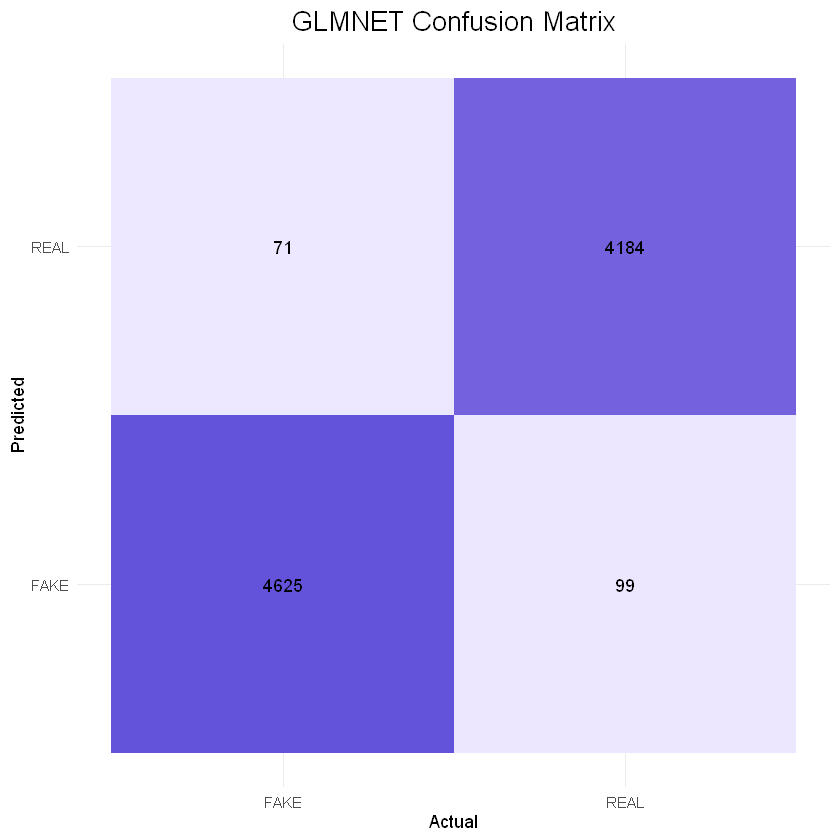

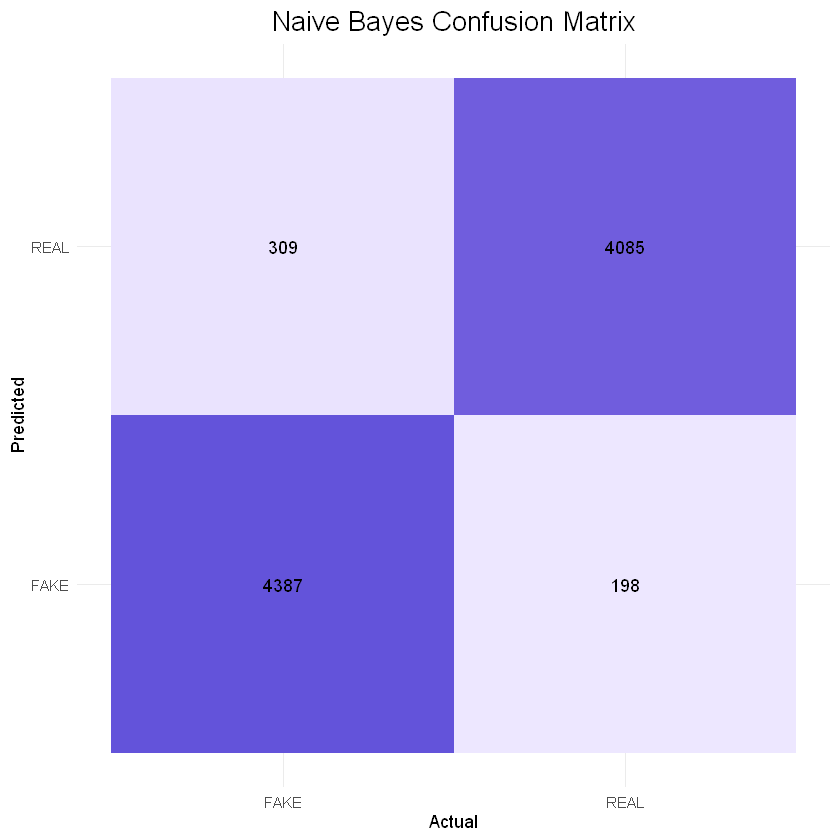

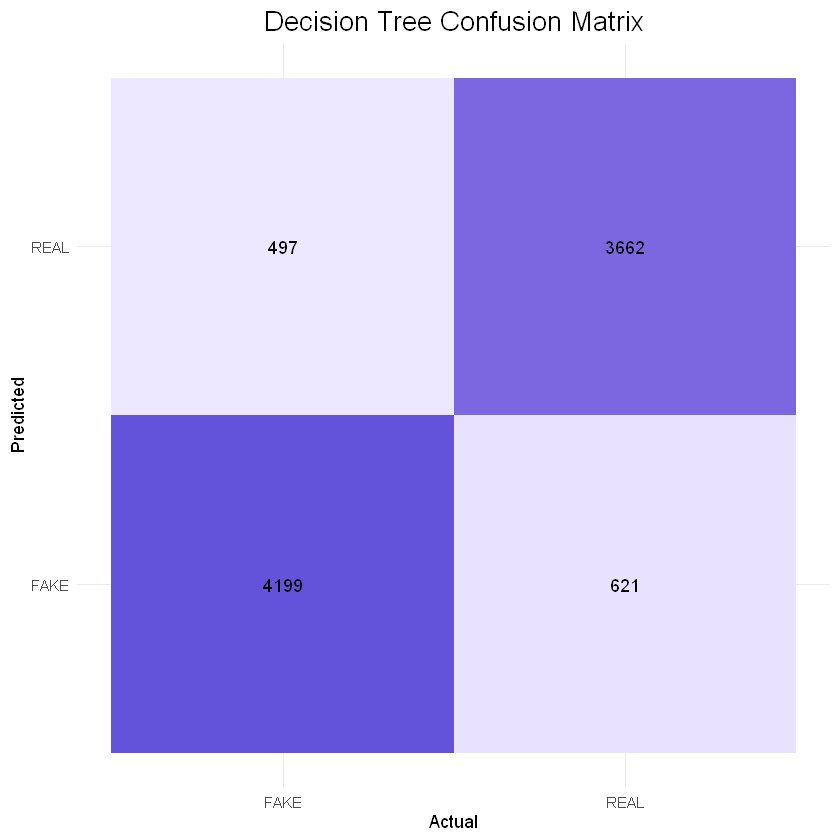

In [101]:
# ==============================================================
# CELL 11: Confusion Matrices
# ==============================================================

plot_confusion_matrix <- function(cm, title) {
  stopifnot(!is.null(cm$table))

  df <- as.data.frame(cm$table)
  names(df) <- c("Predicted", "Actual", "Count")

  ggplot(df, aes(x = Actual, y = Predicted, fill = Count)) +
    geom_tile() +
    geom_text(aes(label = Count)) +
    theme_minimal() +
    labs(title = title) +
    theme(plot.title = element_text(hjust = 0.5, size = 16)) + # centers the title and makes it larger
    guides(fill = "none") + # gets rid of the legend
    scale_fill_gradient(low = "#ede7ffff", high = "#6353daff")
}
print(plot_confusion_matrix(glmnet_cm, "GLMNET Confusion Matrix"))
print(plot_confusion_matrix(nb_cm, "Naive Bayes Confusion Matrix"))
print(plot_confusion_matrix(tree_cm, "Decision Tree Confusion Matrix"))

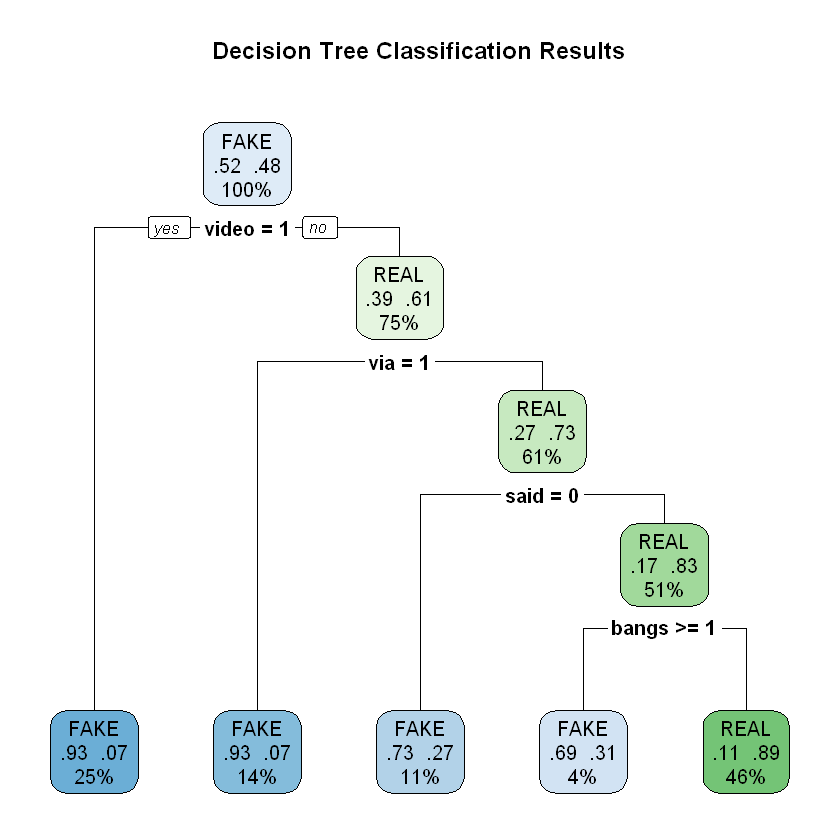

In [102]:
# ==============================================================
# CELL 12: Visualizing Decision Tree
# ==============================================================

rpart.plot(
  tree_fit$finalModel,
  type = 2,
  extra = 104,          # class + probability + percent at leaves
  fallen.leaves = TRUE,
  main = "Decision Tree Classification Results"
)